# Baseline Linear Regression

### What the baseline setup should contain

1. Objective
2. Define X and y
3. Train/Test Split
4. Separate feature types
5. Preprocessing
6. Baseline Linear Regression
7. Evaluate on validation/test data
8. Record baseline results
9. Baseline interpretation

## 1. Objective

The objective of this notebook is to establish a baseline performance
for predicting `median_house_value` using Linear Regression.

This baseline will provide a reference point for subsequent experiments
investigating training data size, number of features, feature selection,
geographic information, feature scaling, model complexity, regularization,
and outlier sensitivity.

The baseline should use a relatively simple and reproducible modeling
pipeline so that changes in performance can be attributed to subsequent
experimental modifications.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../Data/Raw/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 2. Define X and y


In [4]:
X = df.drop(columns=["median_house_value"])

In [5]:
y =df['median_house_value']

In [6]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 3. Train Test Split the Data

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)



### 4. Seprate Numerical Features and Categorical Feature


In [23]:
numerical_features = X_train.select_dtypes(include=('int64', 'float64')).columns

categorical_features = X_train.select_dtypes(include=('str','object')).columns


### 5. Preprocessing
Build the preprocessing pipeline

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical Pipeline
numerical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scalar', StandardScaler())
])

# Categorical Pipeline (FIXED)
categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')), # Added to handle missing strings
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

# Applying the Transformation 
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('Cat', categorical_pipeline, categorical_features)
])


### 6. Train the baseline Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression


baseline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [26]:
#Training the Model
baseline_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('Cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

### 7. Evaluate on validation/test data

In [27]:
y_pred = baseline_lr.predict(X_test)

In [28]:
#importing evaluation metrices from sklearn
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

rmse = root_mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Baseline RMSE:", rmse)
print("Baseline MAE:", mae)
print("Baseline r2_Score:", r2)

Baseline RMSE: 69963.64394056388
Baseline MAE: 50332.302246526866
Baseline r2_Score: 0.6430135661986702


### 8. Baseline Model Results 

In [29]:
baseline_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "RMSE": [rmse],
    "MAE": [mae],
    "R2": [r2]
})

baseline_results

,Model,RMSE,MAE,R2
0,Linear Regression,69963.643941,50332.302247,0.643014


### 9. Baseline Model Interpretation

The baseline Linear Regression model achieved the following performance
on the held-out test set:

| Metric | Score |
|---|---:|
| RMSE | 69,963.64 |
| MAE | 50,332.30 |
| R² | 0.6430 |

The model explains approximately 64.3% of the variance in
`median_house_value`.

The MAE indicates that the average absolute prediction error is
approximately $50,332, while the RMSE is approximately $69,964. The
higher RMSE indicates that some observations produce substantially
larger prediction errors.

These results establish the baseline against which subsequent
experiments will be compared.

In [30]:
y_train_pred = baseline_lr.predict(X_train)
y_test_pred = baseline_lr.predict(X_test)

train_rmse = root_mean_squared_error(
    y_train,
    y_train_pred
) 

test_rmse = root_mean_squared_error(
    y_test,
    y_test_pred
) 

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train RMSE: 68425.01797495961
Test RMSE: 69963.64394056388
Train R²: 0.6456733198584361
Test R²: 0.6430135661986702


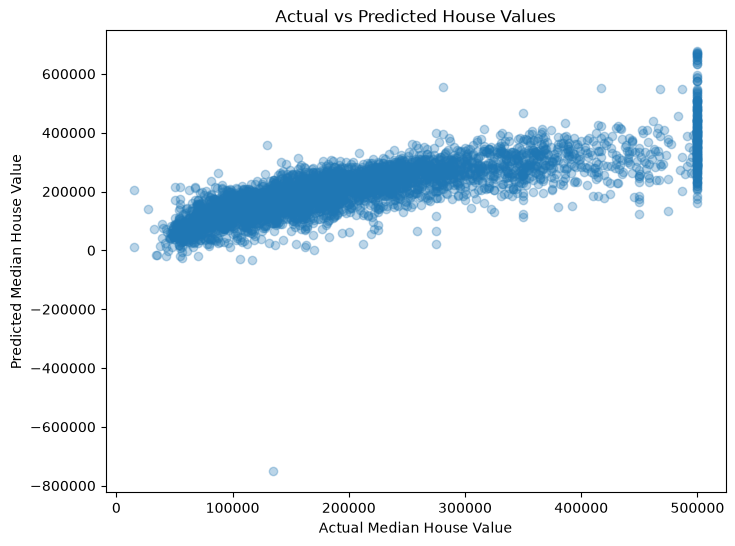

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.3
)

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

In [33]:
residuals = y_test - y_test_pred
residuals

6906     -33456.565743
767      -18159.596302
10555      9740.367795
17456   -130852.225285
20617    -36990.580715
             ...      
8822      25038.930410
4099    -103664.134294
1126      16659.245425
16149     86242.706510
3969     -17162.156822
Name: median_house_value, Length: 4128, dtype: float64

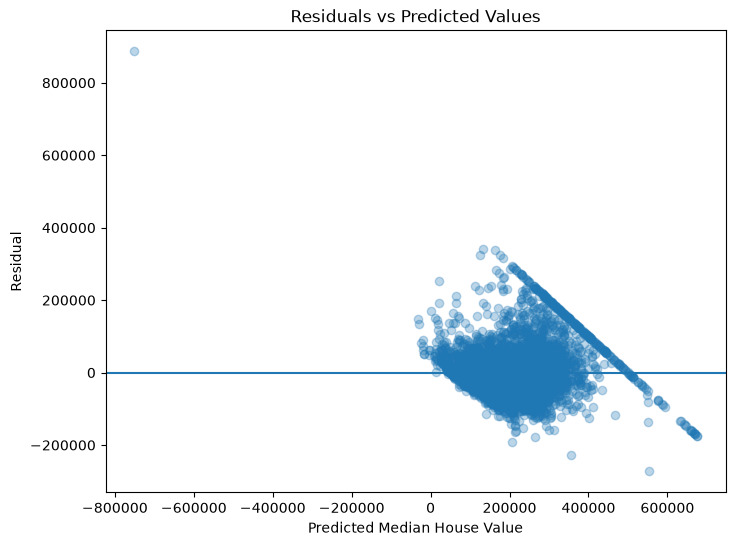

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.3
)

plt.axhline(0)

plt.xlabel("Predicted Median House Value")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.show()

##  Baseline Model Analysis

### Actual vs Predicted

The actual-versus-predicted plot shows a clear positive relationship
between the observed and predicted house values, indicating that the
Linear Regression model has captured a substantial portion of the
underlying relationship.

However, prediction errors become more pronounced at higher house
values. In particular, observations near the upper target boundary of
$500,000 are frequently underpredicted.

The model also produces some extreme predictions, including an
implausibly negative predicted house value. This indicates that the
unconstrained linear model can produce extreme predictions for some
observations.

### Residual Analysis

The residuals are not randomly distributed around zero. Instead, the
residual plot shows systematic structure and increasing dispersion,
suggesting that the linear model does not capture all of the underlying
relationships in the data.

A pronounced diagonal pattern is also visible for observations near the
$500,000 target boundary. This is consistent with the upper-bound effect
identified during EDA.

Overall, the residual analysis suggests that the baseline Linear
Regression model provides a useful starting point but does not fully
capture the nonlinear and spatial structure identified during EDA.

In [35]:
from sklearn.linear_model import SGDRegressor

baseline_sgd = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SGDRegressor())
])

In [36]:
baseline_sgd.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('Cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [40]:
y_pred1 = baseline_sgd.predict(X_test)

In [42]:
rmse = root_mean_squared_error(y_test,y_pred1)
mae = mean_absolute_error(y_test, y_pred1)
r2 = r2_score(y_test, y_pred1)

print("Baseline_SGD RMSE:", rmse)
print("Baseline_SGD MAE:", mae)
print("Baseline_SGD r2_Score:", r2)

Baseline_SGD RMSE: 69959.97535128036
Baseline_SGD MAE: 49921.59818737571
Baseline_SGD r2_Score: 0.6430510028499314
